# Phase 2 — Shared-backbone OCR head (one backbone, two heads)

Instead of an external EasyOCR mask, a lightweight **text head** reads the shared **Visual Perception
Head (VPH)** features and predicts the text mask *inside* the model; that mask is fused into the decoder
(same `TextPriorFusion` as Phase 1). EasyOCR is used only at **training** time to supervise the head
(pseudo-labels) — at inference the head runs standalone, so **no second backbone / no EasyOCR**.

Loss = tampering loss (`CombinedTamperLoss`) + `LAMBDA_TEXT` * BCE(text head, EasyOCR pseudo-mask).

**Untested end-to-end by me** — the one thing to verify is the VPH probe in the Phase-2 arm (it prints
the captured feature shapes; pick `TEXT_FEAT_IDX` from those). This is primarily an architecture/
efficiency contribution, not an accuracy lever on in-distribution FCD.

In [1]:
# --- Setup ---
from google.colab import drive
drive.mount('/content/drive')

import os, sys
%cd /content
if not os.path.exists('/content/DocTamper'):
    !git clone -q https://github.com/qcf-568/DocTamper.git
if not os.path.exists('/content/HLCV-Project'):
    !git clone -q https://github.com/SamiraAbedini/HLCV-Project.git

!pip -q install lmdb six albumentations timm==0.4.12 segmentation_models_pytorch==0.2.1 easyocr
!pip -q install efficientnet_pytorch==0.7.1
!pip -q uninstall -y jpegio
!apt-get -qq install -y libjpeg-dev > /dev/null
!rm -rf /content/jpegio && git clone -q https://github.com/dwgoon/jpegio.git /content/jpegio
%cd /content/jpegio
!pip -q install .
%cd /content/DocTamper/models

sys.path.append('/content/HLCV-Project')
import jpegio
print('jpegio.read available:', hasattr(jpegio, 'read'))

Mounted at /content/drive
/content
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.8/58.8 kB 6.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 377.0/377.0 kB 35.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88.6/88.6 kB 9.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 338.3/338.3 kB 36.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 113.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 180.7/180.7 kB 18.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 978.2/978.2 kB 67.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 296.2/296.2 kB 28.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
segmentation-models-pytorc

In [2]:
# --- Stage data + pickles + backbones ---
import os, glob, getpass
%cd /content/DocTamper/models

ROOTS = 'DocTamperV1-FCD'
MINQ  = 75

if not os.path.exists('qt_table.pk'):
    !cp ../qt_table.pk ./
if not os.path.exists('pks'):
    !cp -r ../pks ./

ZIP_PATH = '/content/drive/MyDrive/DocTamperV1-FCD.zip'
if not os.path.exists(f'{ROOTS}/data.mdb'):
    found = glob.glob(f'/content/**/{ROOTS}/data.mdb', recursive=True)
    if found:
        !ln -s "{os.path.dirname(found[0])}" "./{ROOTS}"
    else:
        assert os.path.exists(ZIP_PATH), f'Dataset zip not found: {ZIP_PATH}'
        pw = getpass.getpass('DocTamper zip password: ')
        !unzip -P "$pw" "{ZIP_PATH}" -d ./
        del pw
assert os.path.exists(f'{ROOTS}/data.mdb'), f'Expected {ROOTS}/data.mdb.'

CKPT_DIR = '/content/drive/MyDrive/checkpoints'
for f in ['vph_imagenet.pt', 'swin_imagenet.pt', 'dtd_doctamper.pth']:
    if not os.path.exists(f) and os.path.exists(os.path.join(CKPT_DIR, f)):
        !cp "{CKPT_DIR}/{f}" ./
for f in ['vph_imagenet.pt', 'swin_imagenet.pt']:
    assert os.path.exists(f), f'{f} not found. Put the checkpoints folder in {CKPT_DIR}.'
print('staging done.')

/content/DocTamper/models
DocTamper zip password: ··········
Archive:  /content/drive/MyDrive/DocTamperV1-FCD.zip
   creating: ./DocTamperV1-FCD/
  inflating: ./__MACOSX/._DocTamperV1-FCD  
  inflating: ./DocTamperV1-FCD/lock.mdb  
  inflating: ./__MACOSX/DocTamperV1-FCD/._lock.mdb  
  inflating: ./DocTamperV1-FCD/data.mdb  
  inflating: ./__MACOSX/DocTamperV1-FCD/._data.mdb  
staging done.


In [3]:
# --- Dataset + disjoint train/eval split (2000-image subset) ---
import ast, torch
from torch.utils.data import DataLoader, Subset
%cd /content/DocTamper/models

SUBSET_SIZE, EVAL_SIZE, TRAIN_STEPS, BATCH = 2000, 400, 800, 4

src = open('eval_dtd.py').read()
tree = ast.parse(src)
keep = [n for n in tree.body
        if isinstance(n, (ast.Import, ast.ImportFrom))
        or (isinstance(n, ast.ClassDef) and n.name in ('TamperDataset', 'IOUMetric'))]
ns = {}
exec(compile(ast.Module(body=keep, type_ignores=[]), 'eval_dtd_extract', 'exec'), ns)
TamperDataset = ns['TamperDataset']

dataset = TamperDataset(ROOTS, mode='train', minq=MINQ)
N = min(SUBSET_SIZE, len(dataset))
eval_idx  = list(range(EVAL_SIZE))
train_idx = list(range(EVAL_SIZE, N))
train_loader = DataLoader(Subset(dataset, train_idx), batch_size=BATCH, shuffle=True,  num_workers=0, drop_last=True)
eval_loader  = DataLoader(Subset(dataset, eval_idx),  batch_size=BATCH, shuffle=False, num_workers=0)
print(f'subset {N} | train {len(train_idx)} | eval {len(eval_idx)}')

/content/DocTamper/models
subset 2000 | train 1600 | eval 400


/content/DocTamper/models/dtd.py:320: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  @autocast()


In [4]:
# --- Model builder + loss + forward ---
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.cuda.amp import autocast, GradScaler

_ORIG_LOAD = torch.load
torch.load = lambda *a, **k: _ORIG_LOAD(*a, **{**k, 'weights_only': False})
from dtd import *
from src.losses import CombinedTamperLoss

device = 'cuda'
FINETUNE_PTH = 'dtd_doctamper.pth'
criterion = CombinedTamperLoss(lambda_dice=1.0, lambda_bound=0.5)

def build_model():
    m = seg_dtd('', 2).to(device)
    for mod in m.modules():
        if isinstance(mod, nn.GELU) and not hasattr(mod, 'approximate'):
            mod.approximate = 'none'
    if FINETUNE_PTH and os.path.exists(FINETUNE_PTH):
        sd = torch.load(FINETUNE_PTH, map_location='cpu')['state_dict']
        sd = {k.replace('module.', ''): v for k, v in sd.items()}
        m.load_state_dict(sd, strict=False)
    return m

def forward_dtd(model, batch):
    return model(batch['image'].to(device), batch['rgb'].to(device), batch['q'].unsqueeze(1).to(device))

print('build_model() ready')

build_model() ready


In [5]:
# --- Pseudo-label OCR (training only) + fusion + text head ---
import numpy as np, easyocr
from src.text_prior import OCRTextMasker
from src.fusion import TextPriorFusion

reader = easyocr.Reader(['en'], gpu=True)
masker = OCRTextMasker(
    lambda im: [p for (p, _, _) in reader.readtext(im, detail=1, paragraph=False)],
    polygon=True, dilate=5)
MEAN = np.array([0.485, 0.455, 0.406]); STD = np.array([0.229, 0.224, 0.225])
def batch_text_masks(images):            # EasyOCR pseudo-labels for the text head (TRAINING only)
    out = []
    for img in images:
        a = img.permute(1, 2, 0).cpu().numpy() * STD + MEAN
        out.append(masker(np.clip(a * 255, 0, 255).astype(np.uint8)))
    return torch.from_numpy(np.stack(out)[:, None]).float().to(device)

class HeadWithPrior(nn.Module):
    def __init__(self, head, in_ch):
        super().__init__()
        self.fusion = TextPriorFusion(in_ch); self.head = head; self.text_mask = None
    def forward(self, feat):
        return self.head(self.fusion(feat, self.text_mask))

class TextHead(nn.Module):
    """Lightweight text-detection head on a shared VPH feature -> 1-channel text logits."""
    def __init__(self, in_ch):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(in_ch, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(True),
            nn.Conv2d(64, 1, 1))
    def forward(self, feat):
        return self.net(feat)

print('phase-2 components ready')

Progress: |██████████████████████████████████████████████████| 100.0% Complete

Progress: |██████████████████████████████████████████████████| 100.0% Completephase-2 components ready


In [6]:
# --- Wiring: probe VPH features, attach text head + fusion via a forward hook ---
IMG_SIZE = 512

def probe_vph(model):
    """Run one forward and report the shapes of the VPH module's output features."""
    core = model.model
    grabbed = {}
    def ph(m, i, o): grabbed['o'] = o
    h = core.vph.register_forward_hook(ph)
    with torch.no_grad():
        _ = forward_dtd(model, next(iter(train_loader)))
    h.remove()
    feats = grabbed['o']
    feats = list(feats) if isinstance(feats, (list, tuple)) else [feats]
    for i, f in enumerate(feats):
        print(f'  vph feat[{i}] channels={f.shape[1]} spatial={tuple(f.shape[-2:])}')
    return feats

def wire_phase2(model, feat_idx, c_vph):
    """Add TextHead on vph feat[feat_idx]; a forward hook predicts the text mask and feeds the
    fusion head. One backbone (vph), two heads (text + tampering). No dtd.py edit."""
    core = model.model
    if hasattr(core, '_p2_handle'):
        core._p2_handle.remove()
    core.text_head = TextHead(c_vph).to(device)
    head = core.segmentation_head
    while hasattr(head, 'head'):
        head = head.head
    core.segmentation_head = HeadWithPrior(head, head[0].in_channels).to(device)

    def hook(m, i, o):
        feats = list(o) if isinstance(o, (list, tuple)) else [o]
        t = core.text_head(feats[feat_idx])
        t = F.interpolate(t, size=(IMG_SIZE, IMG_SIZE), mode='bilinear', align_corners=False)
        core._text_logits = t
        core.segmentation_head.text_mask = torch.sigmoid(t)
    core._p2_handle = core.vph.register_forward_hook(hook)
    return core

print('wiring helpers ready')

wiring helpers ready


In [7]:
# --- train (plain), train_phase2 (joint loss), evaluate ---
from sklearn.metrics import roc_auc_score
bce = nn.BCEWithLogitsLoss()
LAMBDA_TEXT = 0.5

def _cycle(loader):
    it = iter(loader)
    while True:
        try:
            yield next(it)
        except StopIteration:
            it = iter(loader)

def train(model, loader, steps, lr=1e-4):
    opt = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-2)
    scaler = GradScaler(); model.train(); gen = _cycle(loader)
    for step in range(steps):
        batch = next(gen)
        target = batch['label'].squeeze(1).long().to(device)
        opt.zero_grad()
        with autocast():
            logits = forward_dtd(model, batch)
            if logits.shape[-2:] != target.shape[-2:]:
                logits = F.interpolate(logits, size=target.shape[-2:], mode='bilinear', align_corners=False)
            loss, parts = criterion(logits, target)
        scaler.scale(loss).backward(); scaler.step(opt); scaler.update()
        if step % 50 == 0:
            print(f'  step {step:04d}/{steps} | total {parts["total"]:.4f}')

def train_phase2(model, loader, steps, lr=1e-4):
    core = model.model
    opt = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-2)
    scaler = GradScaler(); model.train(); gen = _cycle(loader)
    for step in range(steps):
        batch = next(gen)
        pseudo = batch_text_masks(batch['image'])                 # EasyOCR pseudo-label (train only)
        target = batch['label'].squeeze(1).long().to(device)
        opt.zero_grad()
        with autocast():
            logits = forward_dtd(model, batch)                    # hook sets core._text_logits
            if logits.shape[-2:] != target.shape[-2:]:
                logits = F.interpolate(logits, size=target.shape[-2:], mode='bilinear', align_corners=False)
            tamper_loss, parts = criterion(logits, target)
            text_loss = bce(core._text_logits.float(), pseudo)
            loss = tamper_loss + LAMBDA_TEXT * text_loss
        scaler.scale(loss).backward(); scaler.step(opt); scaler.update()
        if step % 50 == 0:
            print(f'  step {step:04d}/{steps} | tamper {parts["total"]:.4f} text {text_loss.item():.4f}')

@torch.no_grad()
def evaluate(model, loader):
    """No external OCR: baseline has no prior; Phase 2 fills text_mask via its hook."""
    model.eval()
    tp = fp = fn = 0; probs, labels = [], []
    for batch in loader:
        target = batch['label'].squeeze(1).long().to(device)
        with autocast():
            logits = forward_dtd(model, batch)
            if logits.shape[-2:] != target.shape[-2:]:
                logits = F.interpolate(logits, size=target.shape[-2:], mode='bilinear', align_corners=False)
        prob = torch.softmax(logits.float(), 1)[:, 1]
        pred, gt = prob > 0.5, target.bool()
        tp += (pred & gt).sum().item(); fp += (pred & ~gt).sum().item(); fn += (~pred & gt).sum().item()
        p = prob.flatten().cpu().numpy(); l = gt.flatten().cpu().numpy()
        idx = np.random.choice(len(p), min(20000, len(p)), replace=False)
        probs.append(p[idx]); labels.append(l[idx])
    prec = tp / (tp + fp + 1e-9); rec = tp / (tp + fn + 1e-9)
    y, s = np.concatenate(labels), np.concatenate(probs)
    return {'pixel_f1': 2 * prec * rec / (prec + rec + 1e-9), 'precision': prec, 'recall': rec,
            'iou': tp / (tp + fp + fn + 1e-9),
            'auc': roc_auc_score(y, s) if y.min() != y.max() else float('nan')}

print('train / train_phase2 / evaluate ready')

train / train_phase2 / evaluate ready


In [8]:
# --- Arm A: baseline (same checkpoint start, no text head) ---
results = {}
model = build_model()
train(model, train_loader, steps=TRAIN_STEPS)
results['baseline'] = evaluate(model, eval_loader)
print('baseline:', {k: round(v, 4) for k, v in results['baseline'].items()})

/tmp/ipykernel_574/868357240.py:16: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler(); model.train(); gen = _cycle(loader)
/tmp/ipykernel_574/868357240.py:21: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
/usr/local/lib/python3.12/dist-packages/torch/functional.py:505: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at /pytorch/aten/src/ATen/native/TensorShape.cpp:4381.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


  step 0000/800 | total 1.2144
  step 0050/800 | total 0.9006
  step 0100/800 | total 0.4098
  step 0150/800 | total 0.6120
  step 0200/800 | total 0.3074
  step 0250/800 | total 0.3048
  step 0300/800 | total 0.2725
  step 0350/800 | total 0.4969
  step 0400/800 | total 0.7462
  step 0450/800 | total 0.3786
  step 0500/800 | total 0.5520
  step 0550/800 | total 0.1936
  step 0600/800 | total 0.3064
  step 0650/800 | total 0.2650
  step 0700/800 | total 0.2098
  step 0750/800 | total 0.5711


/tmp/ipykernel_574/868357240.py:57: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


baseline: {'pixel_f1': 0.9551, 'precision': 0.9722, 'recall': 0.9387, 'iou': 0.9141, 'auc': np.float64(0.9938)}


In [9]:
# --- Arm B: Phase 2 (shared-backbone text head) ---
TEXT_FEAT_IDX = 0        # <-- set from the probe output below if feat[0] looks wrong
model = build_model()
print('VPH feature shapes:')
feats = probe_vph(model)
c_vph = feats[TEXT_FEAT_IDX].shape[1]
wire_phase2(model, TEXT_FEAT_IDX, c_vph)
train_phase2(model, train_loader, steps=TRAIN_STEPS)
results['phase2'] = evaluate(model, eval_loader)
torch.save({'state_dict': model.state_dict()}, '/content/drive/MyDrive/dtd_phase2.pth')
print('phase2:', {k: round(v, 4) for k, v in results['phase2'].items()})

VPH feature shapes:
  vph feat[0] channels=96 spatial=(128, 128)
  vph feat[1] channels=192 spatial=(64, 64)
  vph feat[2] channels=384 spatial=(32, 32)
  vph feat[3] channels=768 spatial=(16, 16)


/tmp/ipykernel_574/868357240.py:33: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler(); model.train(); gen = _cycle(loader)
/tmp/ipykernel_574/868357240.py:39: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


  step 0000/800 | tamper 1.6488 text 0.7619
  step 0050/800 | tamper 0.7068 text 0.5893
  step 0100/800 | tamper 0.2928 text 0.5345
  step 0150/800 | tamper 0.6210 text 0.4986
  step 0200/800 | tamper 0.4529 text 0.4801
  step 0250/800 | tamper 0.2200 text 0.4262
  step 0300/800 | tamper 0.5825 text 0.3665
  step 0350/800 | tamper 0.2277 text 0.3732
  step 0400/800 | tamper 0.5245 text 0.3142
  step 0450/800 | tamper 0.4080 text 0.3247
  step 0500/800 | tamper 0.2339 text 0.2976
  step 0550/800 | tamper 0.1581 text 0.3156
  step 0600/800 | tamper 0.5583 text 0.2985
  step 0650/800 | tamper 0.2984 text 0.2996
  step 0700/800 | tamper 0.8044 text 0.3264
  step 0750/800 | tamper 0.3387 text 0.3079


/tmp/ipykernel_574/868357240.py:57: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


phase2: {'pixel_f1': 0.9392, 'precision': 0.9567, 'recall': 0.9222, 'iou': 0.8853, 'auc': np.float64(0.9897)}


In [10]:
# --- Results table ---
cols = ['pixel_f1', 'precision', 'recall', 'iou', 'auc']
print(f'{"arm":<10}' + ''.join(f'{c:>11}' for c in cols))
for arm in ['baseline', 'phase2']:
    if arm in results:
        print(f'{arm:<10}' + ''.join(f'{results[arm][c]:>11.4f}' for c in cols))

arm          pixel_f1  precision     recall        iou        auc
baseline       0.9551     0.9722     0.9387     0.9141     0.9938
phase2         0.9392     0.9567     0.9222     0.8853     0.9897


/tmp/ipykernel_574/1346298616.py:11: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


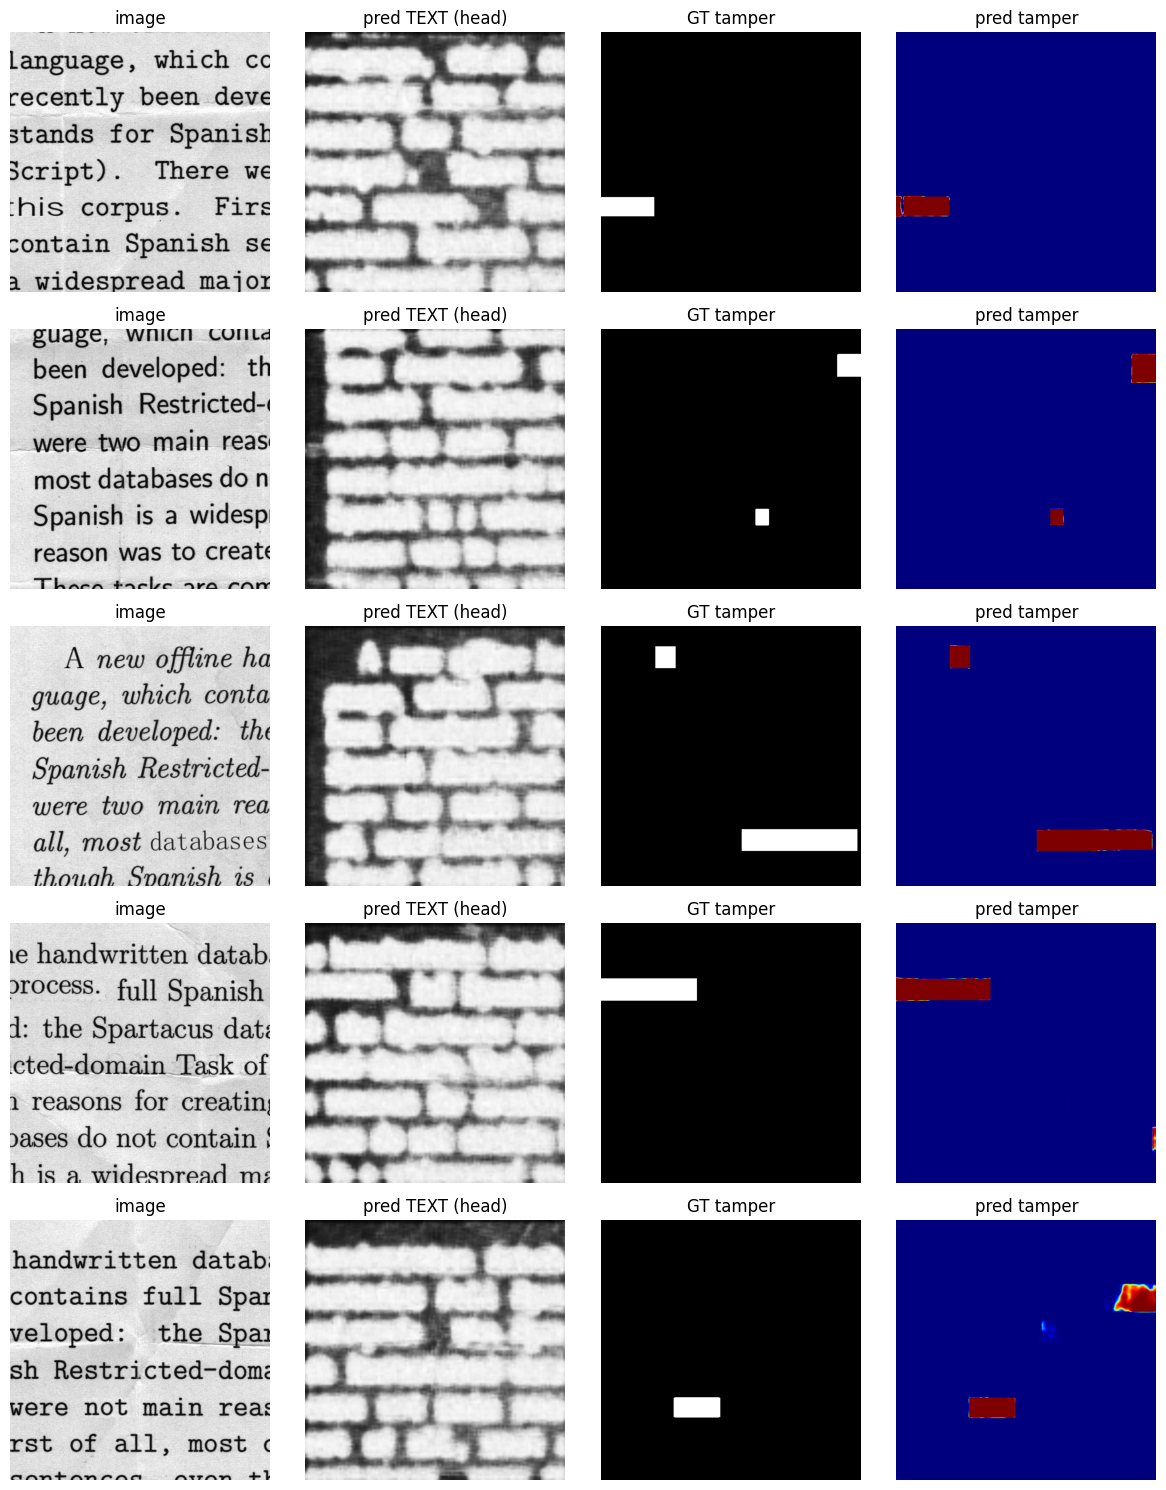

In [11]:
# --- Qualitative: image | predicted TEXT mask (learned head) | GT tamper | predicted tamper ---
import matplotlib.pyplot as plt

def denorm(img):
    a = img.permute(1, 2, 0).cpu().numpy() * STD + MEAN
    return np.clip(a * 255, 0, 255).astype(np.uint8)

model.eval(); core = model.model
batch = next(iter(DataLoader(Subset(dataset, eval_idx), batch_size=6, shuffle=True, num_workers=0)))
with torch.no_grad():
    with autocast():
        logits = forward_dtd(model, batch)
        if logits.shape[-2:] != batch['label'].shape[-2:]:
            logits = F.interpolate(logits, size=batch['label'].shape[-2:], mode='bilinear', align_corners=False)
    tamper = torch.softmax(logits.float(), 1)[:, 1].cpu().numpy()
    text = torch.sigmoid(core._text_logits.float())[:, 0].cpu().numpy()   # learned text head output

N_SHOW = 5
plt.figure(figsize=(12, 3 * N_SHOW))
for i in range(N_SHOW):
    cells = [(denorm(batch['image'][i]), 'image', {}),
             (text[i], 'pred TEXT (head)', dict(cmap='gray', vmin=0, vmax=1)),
             (batch['label'][i, 0].numpy(), 'GT tamper', dict(cmap='gray')),
             (tamper[i], 'pred tamper', dict(cmap='jet', vmin=0, vmax=1))]
    for j, (im, t, kw) in enumerate(cells):
        plt.subplot(N_SHOW, 4, 4 * i + j + 1); plt.imshow(im, **kw); plt.title(t); plt.axis('off')
plt.tight_layout(); plt.show()